# 08 - Final model

Toma el modelo ganador de `07_model_evaluation.ipynb` (por Recall de churn) y afina sus
hiperparametros con `GridSearchCV` (`scoring="recall"`, 5-fold) sobre `train_encoded`. La
comparacion de candidatos ya se hizo en 07 -- aqui no se vuelve a comparar contra los otros
3 modelos, solo se optimiza el ganador y se valida una vez en test.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_style("whitegrid")

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"

train_encoded = pd.read_parquet(f"{PROCESSED_DIR}/train_encoded.parquet")
test_encoded = pd.read_parquet(f"{PROCESSED_DIR}/test_encoded.parquet")
X_train = train_encoded.drop(columns=["churn_flag"])
y_train = train_encoded["churn_flag"]
X_test = test_encoded.drop(columns=["churn_flag"])
y_test = test_encoded["churn_flag"]

with open(f"{MODELS_DIR}/best_model_name.txt") as f:
    BEST_MODEL_NAME = f.read().strip()

print(f"Modelo a afinar: {BEST_MODEL_NAME}")

Modelo a afinar: logistic_regression


## Grid de hiperparametros por modelo

Un grid por candidato posible -- este notebook funciona sin importar cual de los 4 modelos
haya ganado en 07.

In [2]:
ESTIMATORS = {
    "logistic_regression": (
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
        {"clf__C": [0.01, 0.1, 1, 10]},
    ),
    "decision_tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [4, 6, 8, 10, None], "min_samples_split": [2, 5, 10]},
    ),
    "random_forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {"n_estimators": [200, 300], "max_depth": [8, 10, 12], "min_samples_split": [2, 5]},
    ),
    "xgboost": (
        XGBClassifier(random_state=42, eval_metric="logloss"),
        {"n_estimators": [200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1]},
    ),
}

base_estimator, param_grid = ESTIMATORS[BEST_MODEL_NAME]

search = GridSearchCV(base_estimator, param_grid, cv=5, scoring="recall", n_jobs=-1)
search.fit(X_train, y_train)

print(f"Mejores hiperparametros: {search.best_params_}")
print(f"Recall promedio (cross-validation, train): {search.best_score_:.3f}")

Mejores hiperparametros: {'clf__C': 0.1}
Recall promedio (cross-validation, train): 0.663


## Validar en test (una sola vez)

In [3]:
tuned_model = search.best_estimator_
y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"ROC_AUC:   {roc_auc_score(y_test, y_proba):.3f}")

Accuracy:  0.831
Precision: 0.708
Recall:    0.704
F1:        0.706
ROC_AUC:   0.866


## Threshold tuning

El umbral por defecto (0.5) no esta atado a ningun objetivo de negocio -- es solo el punto
medio de la probabilidad. Como el objetivo es maximizar Recall, se recorre la curva
precision-recall para elegir el umbral mas bajo que siga dando una Precision razonable (que
el equipo de retencion no reciba una lista dominada por falsos positivos).

In [4]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

MIN_PRECISION = 0.55
valid = precisions[:-1] >= MIN_PRECISION
if valid.any():
    CHOSEN_THRESHOLD = thresholds[valid][recalls[:-1][valid].argmax()]
else:
    CHOSEN_THRESHOLD = 0.5

y_pred_tuned_threshold = (y_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"Umbral elegido: {CHOSEN_THRESHOLD:.3f} (Precision minima exigida: {MIN_PRECISION})")
print(f"Recall con este umbral:    {recall_score(y_test, y_pred_tuned_threshold):.3f}")
print(f"Precision con este umbral: {precision_score(y_test, y_pred_tuned_threshold):.3f}")

Umbral elegido: 0.255 (Precision minima exigida: 0.55)
Recall con este umbral:    0.824
Precision con este umbral: 0.551


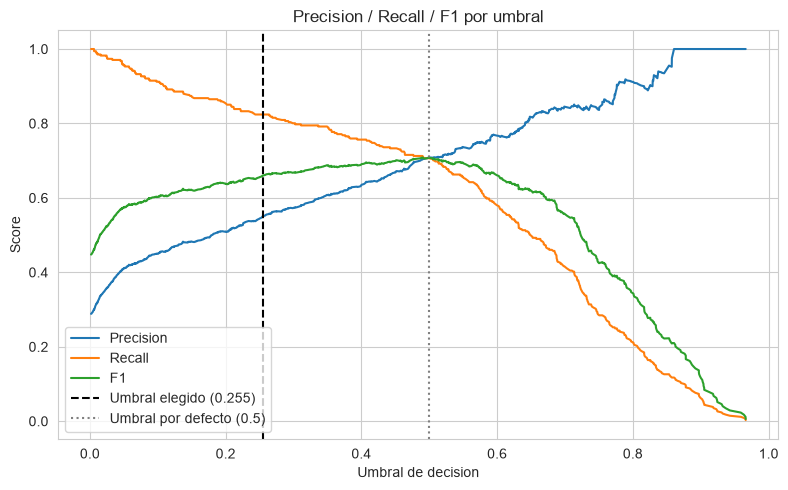

In [5]:
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1")
plt.axvline(CHOSEN_THRESHOLD, color="black", linestyle="--", label=f"Umbral elegido ({CHOSEN_THRESHOLD:.3f})")
plt.axvline(0.5, color="gray", linestyle=":", label="Umbral por defecto (0.5)")
plt.xlabel("Umbral de decision")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 por umbral")
plt.legend()
plt.tight_layout()
plt.show()

## Persistir metricas del modelo desplegado (para la pagina Model Performance)

Este es el notebook del modelo que efectivamente se despliega, asi que de aca deben salir
las metricas que ve el dashboard -- calculadas con el **umbral operativo**
(`CHOSEN_THRESHOLD`), no con el 0.5 por defecto que uso `07`. `ROC_AUC` es la excepcion: es
independiente del umbral (mide separabilidad sobre todos los cortes posibles), asi que su
valor coincide con el de `07`.

In [6]:
df_final_metrics = pd.DataFrame([{
    "model_name": BEST_MODEL_NAME,
    "threshold": CHOSEN_THRESHOLD,
    "accuracy": accuracy_score(y_test, y_pred_tuned_threshold),
    "precision": precision_score(y_test, y_pred_tuned_threshold),
    "recall": recall_score(y_test, y_pred_tuned_threshold),
    "f1": f1_score(y_test, y_pred_tuned_threshold),
    "roc_auc": roc_auc_score(y_test, y_proba),
}])
df_final_metrics.to_csv(f"{PROCESSED_DIR}/model_final_metrics.csv", index=False)
print("Guardado: model_final_metrics.csv")
df_final_metrics

Guardado: model_final_metrics.csv


,model_name,threshold,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.254519,0.755499,0.55098,0.824047,0.6604,0.866184


In [7]:
cm = confusion_matrix(y_test, y_pred_tuned_threshold)  # filas=actual [Stayed, Churn], cols=predicted [Stayed, Churn]

df_confusion_matrix = pd.DataFrame(
    [
        {"actual": "Stayed", "predicted": "Stayed", "customers": cm[0, 0]},
        {"actual": "Stayed", "predicted": "Churn", "customers": cm[0, 1]},
        {"actual": "Churn", "predicted": "Stayed", "customers": cm[1, 0]},
        {"actual": "Churn", "predicted": "Churn", "customers": cm[1, 1]},
    ]
)
df_confusion_matrix.to_csv(f"{PROCESSED_DIR}/model_confusion_matrix.csv", index=False)
print("Guardado: model_confusion_matrix.csv")
print(f"Total (debe ser {len(y_test)}): {df_confusion_matrix['customers'].sum()}")
df_confusion_matrix

Guardado: model_confusion_matrix.csv
Total (debe ser 1182): 1182


,actual,predicted,customers
0,Stayed,Stayed,612
1,Stayed,Churn,229
2,Churn,Stayed,60
3,Churn,Churn,281


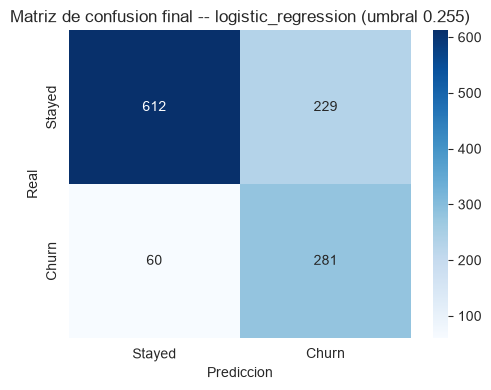

In [8]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Stayed", "Churn"], yticklabels=["Stayed", "Churn"])
plt.title(f"Matriz de confusion final -- {BEST_MODEL_NAME} (umbral {CHOSEN_THRESHOLD:.3f})")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

# roc_curve devuelve un punto por umbral unico visto en y_proba (hasta len(y_test)+1) --
# se submuestrea a ~200 puntos para no inflar el DirectQuery en Power BI. Se conservan
# siempre el primer y ultimo punto (0,0) y (1,1) para que la curva no se corte.
MAX_POINTS = 200
if len(fpr) > MAX_POINTS:
    idx = np.linspace(0, len(fpr) - 1, MAX_POINTS, dtype=int)
    idx = np.unique(np.concatenate([[0], idx, [len(fpr) - 1]]))
else:
    idx = np.arange(len(fpr))

df_roc_curve = pd.DataFrame({"fpr": fpr[idx], "tpr": tpr[idx]})
df_roc_curve.to_csv(f"{PROCESSED_DIR}/model_roc_curve.csv", index=False)
print(f"Guardado: model_roc_curve.csv ({len(df_roc_curve)} puntos)")

Guardado: model_roc_curve.csv (200 puntos)


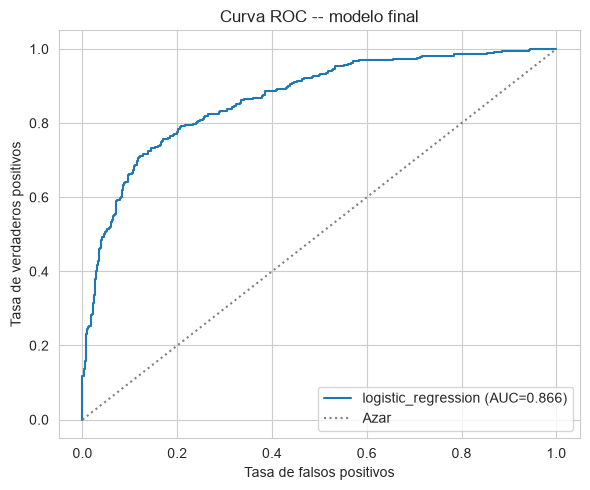

In [10]:
final_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{BEST_MODEL_NAME} (AUC={final_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC -- modelo final")
plt.legend()
plt.tight_layout()
plt.show()

## Guardar el modelo final

In [11]:
joblib.dump(
    {"model": tuned_model, "threshold": CHOSEN_THRESHOLD, "model_name": BEST_MODEL_NAME},
    f"{MODELS_DIR}/final_model.joblib",
)
print(f"Guardado: final_model.joblib ({BEST_MODEL_NAME}, threshold={CHOSEN_THRESHOLD:.3f})")

Guardado: final_model.joblib (logistic_regression, threshold=0.255)
